<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB04_Quality_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04: Quality Control & Filtration
Bu notebook, üretilen sentetik verilerdeki anlamsal sapmaları (Quality), tekrarları (Duplicates) ve test setine sızan örnekleri (Leakage) tespit edip eler.
İşlem adımları:
1. Sabit embedding modeli ve karantina havuzunun (val+test) yüklenmesi
2. Her kaynak seviyesi (low, normal), her tohum (0..9) ve her yöntem (BT, LLM) için otomatik filtreleme.
3. Retention (Hayatta Kalma) Oranlarının Hesaplanması.
4. (Sadece Low) Manuel Denetim için örneklem çekilmesi.
5. Benzerlik dağılımlarının IEEE formatında görselleştirilmesi.


In [1]:
# 1. Kütüphanelerin Kurulumu ve Yüklenmesi
!pip install -q sentence-transformers pandas numpy matplotlib seaborn pyyaml

import os
import gc
import json
import yaml
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

# Drive Mount (Eğer Colab'da çalışıyorsa)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tr_augmentation_project'
except:
    # Yerel ortam varsayımı
    BASE_DIR = 'C:/Users/btlbi/OneDrive/Masaüstü/TR Veri arttırımı'
    print("Colab ortamı bulunamadı, yerel dizin kullanılıyor:", BASE_DIR)

# Dizinlerin oluşturulması
os.makedirs(os.path.join(BASE_DIR, '03_quality'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '04_filtered'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, '11_figures'), exist_ok=True)


Mounted at /content/drive


In [2]:
# 2. Config ve Karantina (Quarantine) Havuzunun Yüklenmesi

config_path = os.path.join(BASE_DIR, 'configs', 'experiment_config.yaml')
if os.path.exists(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
else:
    # Fallback config
    config = {
        'seeds': {'data_seeds': list(range(10))},
        'quality_filter': {
            'embedding_model': 'emrecan/bert-base-turkish-cased-mean-nli-stsb-tr',
            'cosine_threshold': 0.70
        },
        'leakage_check': {
            'embedding_similarity_threshold': 0.90
        }
    }

COSINE_THRESHOLD = config['quality_filter']['cosine_threshold']
LEAKAGE_THRESHOLD = config['leakage_check']['embedding_similarity_threshold']
MODEL_NAME = config['quality_filter']['embedding_model']
DATA_SEEDS = config['seeds']['data_seeds']

print(f"Cosine Threshold (Quality): {COSINE_THRESHOLD}")
print(f"Leakage Threshold: {LEAKAGE_THRESHOLD}")
print(f"Embedding Model: {MODEL_NAME}")

# Modelin yüklenmesi
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedder = SentenceTransformer(MODEL_NAME, device=device)

# Karantina (Validation + Test) Setinin Okunması
val_path = os.path.join(BASE_DIR, '01_splits', 'fixed', 'validation.csv')
test_path = os.path.join(BASE_DIR, '01_splits', 'fixed', 'test.csv')

quarantine_df = pd.DataFrame()
if os.path.exists(val_path) and os.path.exists(test_path):
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    quarantine_df = pd.concat([val_df, test_df], ignore_index=True)
    print(f"Karantina Havuzu Yüklendi. Toplam Örnek: {len(quarantine_df)}")
else:
    print("UYARI: val_path veya test_path bulunamadı!")

# Karantina havuzunun embedding'lerinin BİR KERE hesaplanması (Performans Optimizasyonu)
quarantine_texts = quarantine_df['text'].dropna().tolist()
if len(quarantine_texts) > 0:
    print("Karantina setinin embeddingleri hesaplanıyor... (Bu işlem bir kere yapılır)")
    quarantine_embeddings = embedder.encode(quarantine_texts, convert_to_tensor=True, batch_size=64, show_progress_bar=True)
else:
    quarantine_embeddings = None


Cosine Threshold (Quality): 0.7
Leakage Threshold: 0.9
Embedding Model: emrecan/bert-base-turkish-cased-mean-nli-stsb-tr


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.26k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/498k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Karantina Havuzu Yüklendi. Toplam Örnek: 44068
Karantina setinin embeddingleri hesaplanıyor... (Bu işlem bir kere yapılır)


Batches:   0%|          | 0/689 [00:00<?, ?it/s]

In [3]:
# 3. Türkçe Karakter Duyarlı Normalizasyon Fonksiyonu

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    # Türkçe'ye özgü küçük harfe çevirme
    translation_table = str.maketrans("Iİ", "ıi")
    text = text.translate(translation_table).lower()

    # Noktalama işaretlerini kaldırma
    import string
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Fazla boşlukları temizleme
    return " ".join(text.split())

# Karantina setinin normalize edilmiş metinlerini (exact match için) önbelleğe alma
quarantine_normalized = set(normalize_text(t) for t in quarantine_texts)


In [5]:
# 4. Ana Filtreleme Döngüsü (Quality, Duplicates, Leakage)

resource_levels = ['low', 'normal']
methods = ['backtranslation', 'llm_paraphrase']

retention_records = []
all_similarities = [] # Çizim için (yöntem, seviye, filtre_öncesi_sonrası, benzerlik)

for level in resource_levels:
    for method in methods:
        for seed in DATA_SEEDS:
            # Okunacak Yollar
            orig_path = os.path.join(BASE_DIR, '01_splits', level, f'seed_{seed}', 'train_seed.csv')
            aug_path = os.path.join(BASE_DIR, '02_augmented', level, method, f'seed_{seed}', 'pool.csv')

            if not (os.path.exists(orig_path) and os.path.exists(aug_path)):
                continue

            orig_df = pd.read_csv(orig_path)
            aug_df = pd.read_csv(aug_path)

            initial_count = len(aug_df)
            if initial_count == 0:
                continue

            # Metinleri eşleştirme (orijinal ve sentetik aynı indekste varsayılıyor - 1:1 üretim)
            # Eğer satır sayıları tutmuyorsa, "id" veya "original_text" üzerinden eşleştirilmelidir.
            # Kod karmaşıklığını önlemek adına doğrudan zip'liyoruz (1:1 üretildiğine emin olun)

            # --- Boş Üretimlerin Loglanması (Akademik Raporlama İçin) ---
            aug_col = 'augmented_text' if 'augmented_text' in aug_df.columns else 'text'
            empty_count = aug_df[aug_col].isna().sum()
            if empty_count > 0:
                print(f"BİLGİ: {method} (seed={seed}, level={level}) içerisinde {empty_count} adet boş/başarısız üretim (NaN) bulundu. Bunlar otomatik olarak elenecek.")

            orig_texts = orig_df['text'].fillna("").astype(str).tolist()
            aug_texts = aug_df[aug_col].fillna("").astype(str).tolist()

            # --- Filtre 1: Quality Filter (Cosine Similarity >= 0.70) ---
            orig_emb = embedder.encode(orig_texts, convert_to_tensor=True, show_progress_bar=False)
            aug_emb = embedder.encode(aug_texts, convert_to_tensor=True, show_progress_bar=False)

            # Çapraz olmayan, ikili kosinüs (pair-wise)
            cos_sims = util.cos_sim(orig_emb, aug_emb).diag().cpu().numpy()

            # Benzerlik skorlarını grafikte kullanmak üzere kaydet
            for sim in cos_sims:
                all_similarities.append({'level': level, 'method': method, 'stage': 'Pre-Filter', 'sim': float(sim)})

            # Filtre Maskesi (>= 0.70 ise True/TUT)
            quality_mask = cos_sims >= COSINE_THRESHOLD

            aug_df['quality_score'] = cos_sims
            aug_df['passed_quality'] = quality_mask

            # --- Filtre 2: İçsel Tekrar (Duplicates) ---
            # Kendi içindeki tekrarları bul (sadece aug_texts içinde)
            aug_df['normalized_aug'] = [normalize_text(t) for t in aug_texts]
            dup_mask = ~aug_df.duplicated(subset=['normalized_aug'], keep='first')
            aug_df['passed_dup'] = dup_mask

            # --- Filtre 3: Leakage Kontrolü (Sızıntı) ---
            leakage_mask = np.ones(initial_count, dtype=bool) # Başta hepsi geçiyor (True)

            if quarantine_embeddings is not None:
                # İkincil kriter: Embedding Similarity < 0.90 (Sızıntı yoku TUT)
                # aug_emb ile quarantine_embeddings arasındaki max benzerliği bul
                cross_sims = util.cos_sim(aug_emb, quarantine_embeddings) # (N_aug, N_quarantine)
                max_sims, _ = torch.max(cross_sims, dim=1)
                max_sims_np = max_sims.cpu().numpy()
                embedding_leakage_mask = max_sims_np < LEAKAGE_THRESHOLD

                # Birincil kriter: Exact Match
                exact_match_mask = ~aug_df['normalized_aug'].isin(quarantine_normalized)

                # Her ikisini de geçmeli
                leakage_mask = embedding_leakage_mask & exact_match_mask

            aug_df['passed_leakage'] = leakage_mask

            # === NİHAİ FİLTRELEME ===
            final_mask = quality_mask & dup_mask & leakage_mask
            filtered_df = aug_df[final_mask].copy()

            # Grafikler için son durumu kaydet
            for sim in filtered_df['quality_score']:
                 all_similarities.append({'level': level, 'method': method, 'stage': 'Post-Filter', 'sim': float(sim)})

            # Kaydetme yolları
            out_dir = os.path.join(BASE_DIR, '04_filtered', level, method, f'seed_{seed}')
            os.makedirs(out_dir, exist_ok=True)

            # Sadece ilgili sütunları tut (temizlik)
            cols_to_keep = [c for c in filtered_df.columns if c not in ['normalized_aug', 'passed_quality', 'passed_dup', 'passed_leakage']]
            filtered_df[cols_to_keep].to_csv(os.path.join(out_dir, 'pool_filtered.csv'), index=False)

            # Belleği temizle
            del orig_emb, aug_emb
            if quarantine_embeddings is not None:
                del cross_sims
            gc.collect()
            torch.cuda.empty_cache()

            # Retention Raporu İçin Kayıt
            retention_records.append({
                'level': level,
                'method': method,
                'seed': seed,
                'initial_count': initial_count,
                'filtered_count': len(filtered_df),
                'retention_rate': len(filtered_df) / initial_count if initial_count > 0 else 0
            })

print("Filtreleme tamamlandı.")

BİLGİ: backtranslation (seed=4, level=normal) içerisinde 1 adet boş/başarısız üretim (NaN) bulundu. Bunlar otomatik olarak elenecek.
Filtreleme tamamlandı.


In [6]:
# 5. Hayatta Kalma (Retention) Raporu Oluşturma

retention_df = pd.DataFrame(retention_records)
if len(retention_df) > 0:
    summary_df = retention_df.groupby(['level', 'method']).agg(
        total_initial=('initial_count', 'sum'),
        total_filtered=('filtered_count', 'sum'),
        mean_retention=('retention_rate', 'mean')
    ).reset_index()

    summary_df['mean_retention_%'] = (summary_df['mean_retention'] * 100).round(2)

    report_path = os.path.join(BASE_DIR, '04_filtered', 'retention_report.csv')
    summary_df.to_csv(report_path, index=False)

    import IPython.display as display
    display.display(summary_df)


,level,method,total_initial,total_filtered,mean_retention,mean_retention_%
0,low,backtranslation,300,246,0.820000,82.00
1,low,llm_paraphrase,300,278,0.926667,92.67
2,normal,backtranslation,3000,2479,0.826333,82.63
3,normal,llm_paraphrase,3000,2816,0.938667,93.87


In [7]:
# 6. Manuel Denetim (Manual Audit) Hazırlığı - SADECE 'low' Koşulunda

audit_dir = os.path.join(BASE_DIR, '03_quality', 'low', 'label_consistency')
os.makedirs(audit_dir, exist_ok=True)

if 'low' in resource_levels:
    print("Low seviyesi için manuel denetim örneklemi çekiliyor...")

    for method in methods:
        # Tüm seed'lerdeki filtrelenmiş verileri topla
        all_filtered_low = []
        for seed in DATA_SEEDS:
            f_path = os.path.join(BASE_DIR, '04_filtered', 'low', method, f'seed_{seed}', 'pool_filtered.csv')
            if os.path.exists(f_path):
                all_filtered_low.append(pd.read_csv(f_path))

        if all_filtered_low:
            merged_low = pd.concat(all_filtered_low, ignore_index=True)

            # Sınıf dengeli rastgele örneklem çek (10'ar tane)
            # Etiket sütunu 'label' varsayılmaktadır.
            label_col = 'label' if 'label' in merged_low.columns else 'sentiment'

            sampled = []
            for label_val in merged_low[label_col].unique():
                class_df = merged_low[merged_low[label_col] == label_val]
                n_sample = min(10, len(class_df))
                sampled.append(class_df.sample(n=n_sample, random_state=42))

            if sampled:
                audit_df = pd.concat(sampled, ignore_index=True)
                # Gözlem sütunlarını ekle
                audit_df['semantic_preserved'] = ""
                audit_df['sentiment_preserved'] = ""
                audit_df['grammatical_quality'] = ""
                audit_df['acceptable'] = ""

                out_path = os.path.join(audit_dir, f'manual_audit_sample_{method}.csv')
                audit_df.to_csv(out_path, index=False)
                print(f"{method} için manuel denetim dosyası oluşturuldu: {out_path} (Toplam: {len(audit_df)} örnek)")


Low seviyesi için manuel denetim örneklemi çekiliyor...
backtranslation için manuel denetim dosyası oluşturuldu: /content/drive/MyDrive/tr_augmentation_project/03_quality/low/label_consistency/manual_audit_sample_backtranslation.csv (Toplam: 30 örnek)
llm_paraphrase için manuel denetim dosyası oluşturuldu: /content/drive/MyDrive/tr_augmentation_project/03_quality/low/label_consistency/manual_audit_sample_llm_paraphrase.csv (Toplam: 30 örnek)


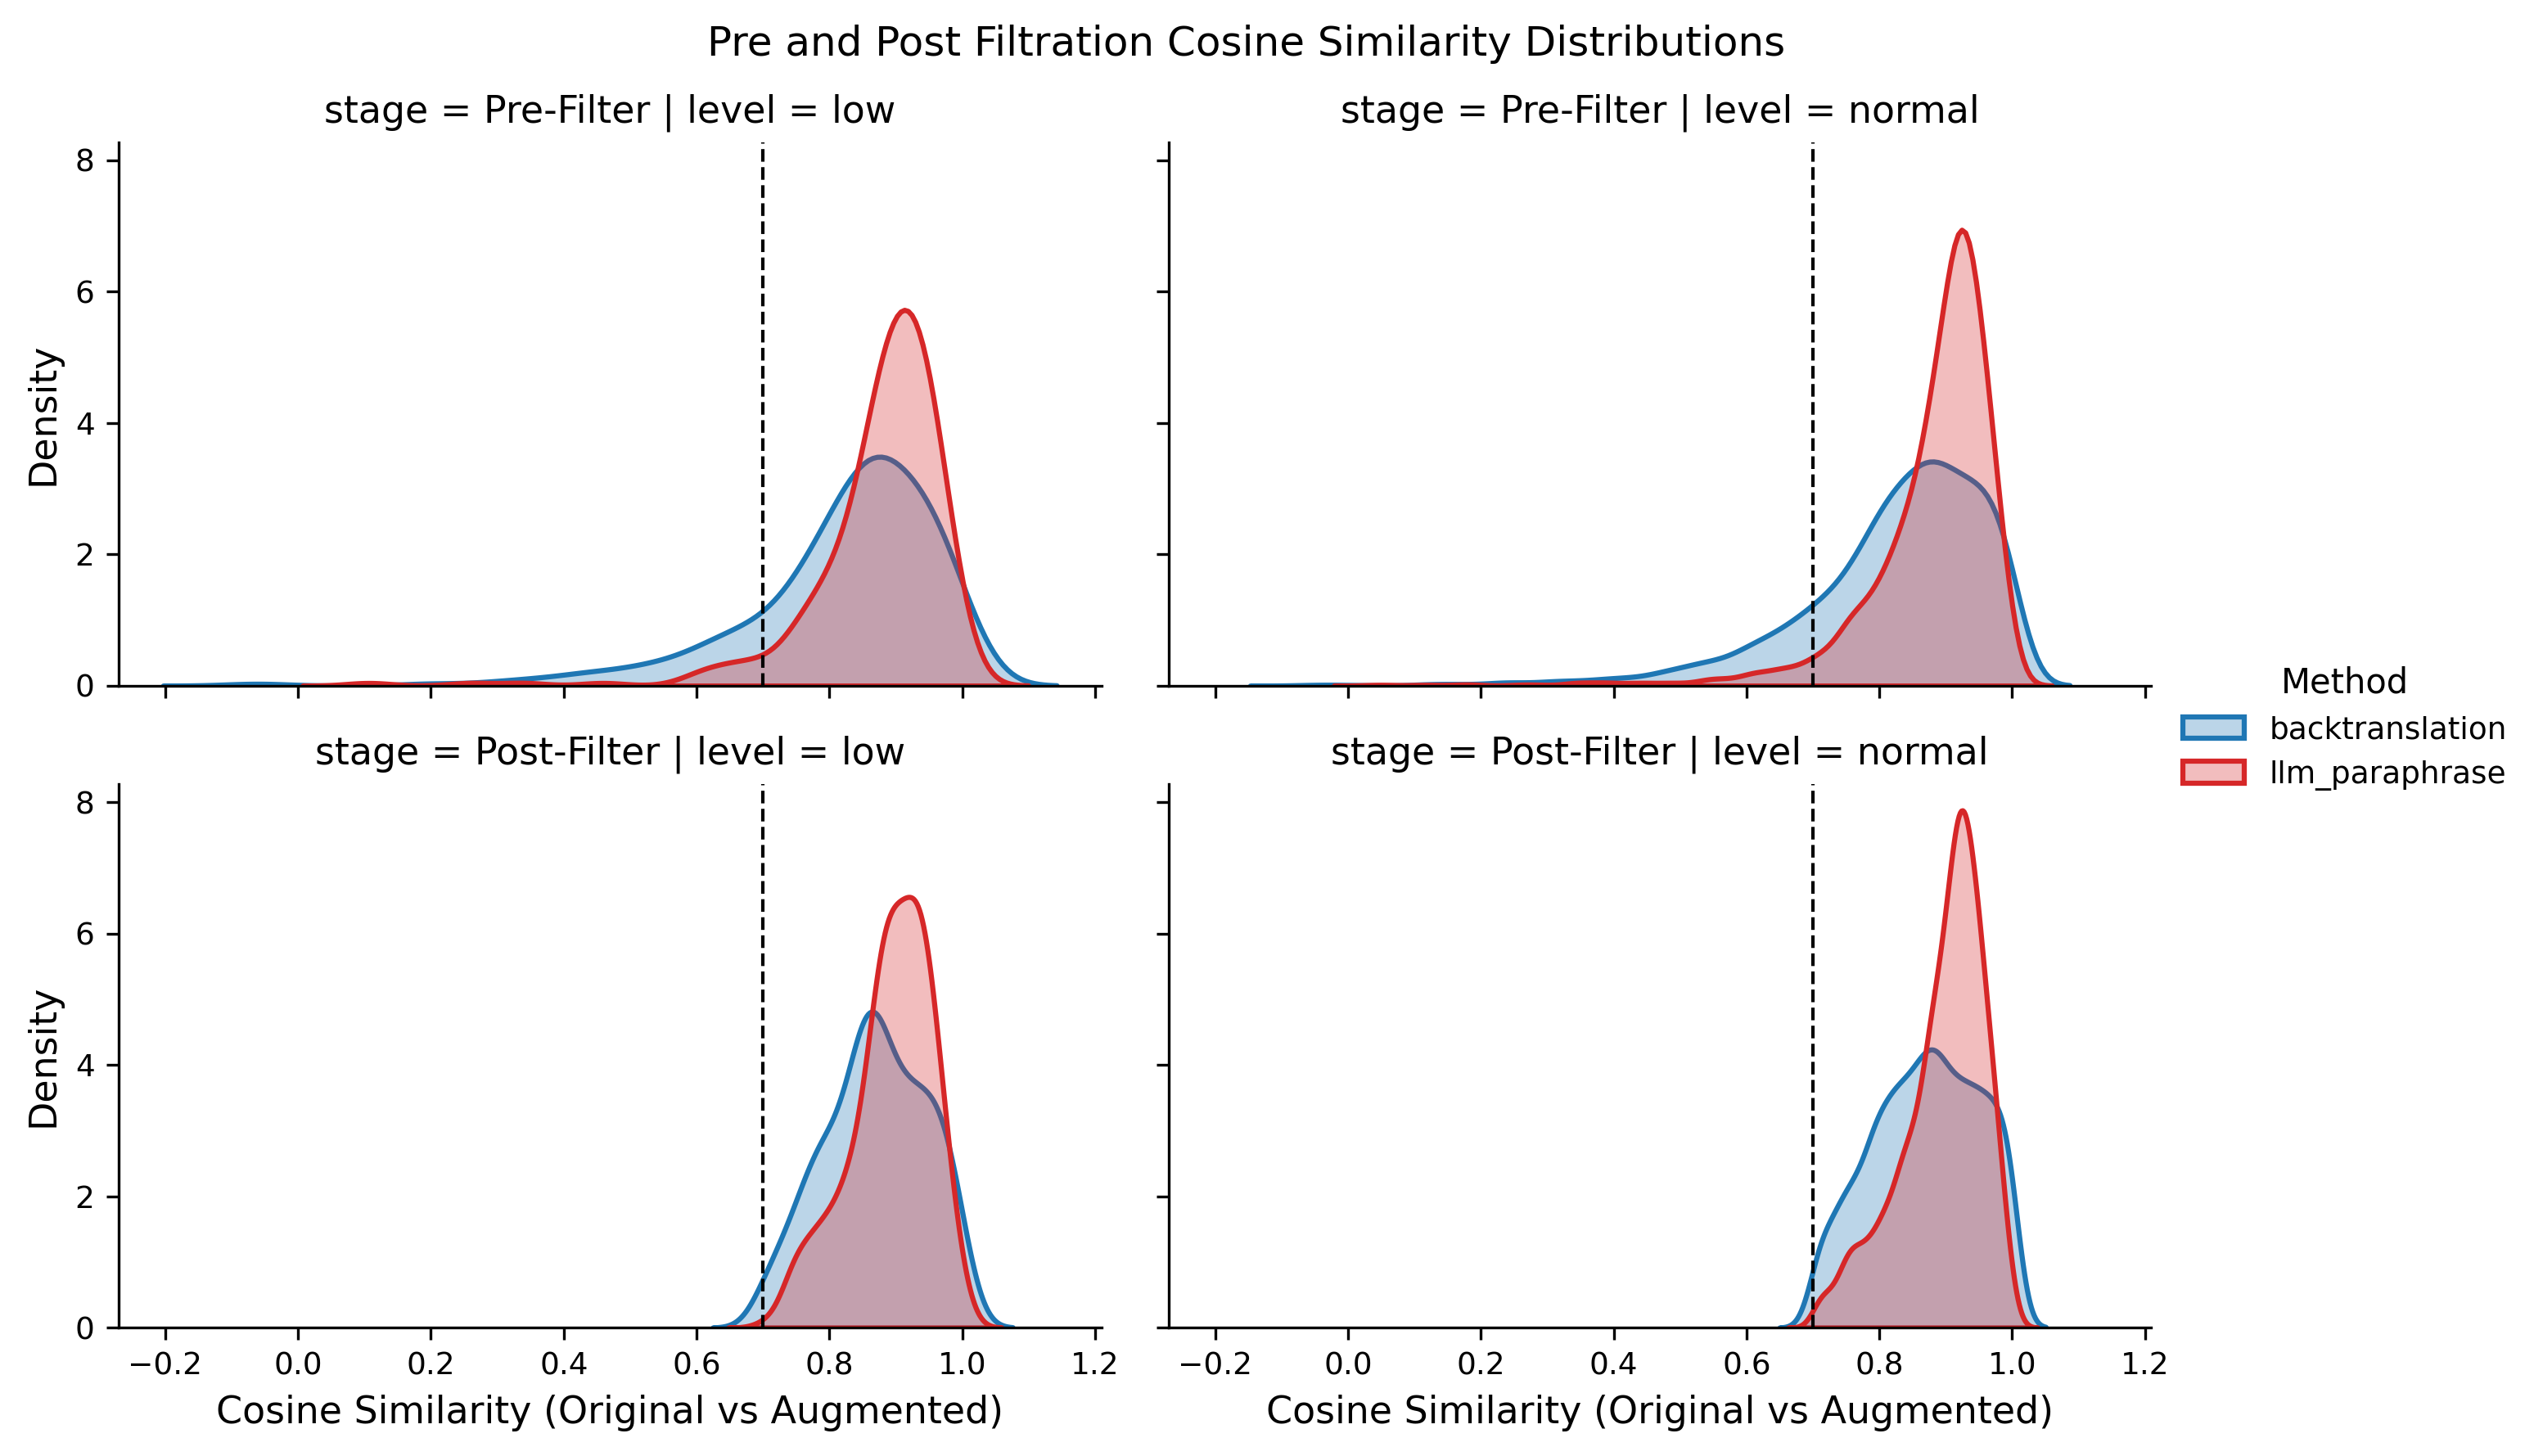

Grafik kaydedildi: /content/drive/MyDrive/tr_augmentation_project/11_figures/similarity_distributions.pdf


In [8]:
# 7. IEEE Formatında Benzerlik Dağılımlarının Görselleştirilmesi

if len(all_similarities) > 0:
    sim_df = pd.DataFrame(all_similarities)

    # IEEE Stil Ayarları
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.dpi': 300,
        'savefig.dpi': 300
    })

    # Siyah beyaz baskı dostu renkler
    colors = {"backtranslation": "#1f77b4", "llm_paraphrase": "#d62728"}

    g = sns.FacetGrid(sim_df, col="level", row="stage", hue="method", palette=colors, aspect=1.5, height=3)
    g.map(sns.kdeplot, "sim", fill=True, alpha=0.3, linewidth=1.5)

    # Eşik çizgisi
    for ax in g.axes.flat:
        ax.axvline(x=COSINE_THRESHOLD, color='k', linestyle='--', linewidth=1)
        ax.set_xlabel('Cosine Similarity (Original vs Augmented)')
        ax.set_ylabel('Density')

    g.add_legend(title='Method')
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Pre and Post Filtration Cosine Similarity Distributions')

    fig_path = os.path.join(BASE_DIR, '11_figures', 'similarity_distributions.pdf')
    plt.savefig(fig_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Grafik kaydedildi: {fig_path}")
